# Daily Challenge: Apple Stock Price Analysis


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, shapiro, ttest_1samp, pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")
print("Environment configured for Apple stock analysis.")

Libraries imported successfully!
Environment configured for Apple stock analysis.


## Task 1: Data Loading and Preprocessing

In [3]:

file_path = 'AppleStockPrice.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except FileNotFoundError:
    print(f"Error: Could not find {file_path}")
except Exception as e:
    print(f"Error loading data: {e}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Check data types and missing values
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Data loaded successfully!
Dataset shape: (2518, 6)
Columns: ['Date', ' Close/Last', ' Volume', ' Open', ' High', ' Low']

First 5 rows:
         Date  Close/Last     Volume      Open      High       Low
0  02/28/2020     $273.36  106721200   $257.26   $278.41   $256.37
1  02/27/2020     $273.52   80151380    $281.1      $286   $272.96
2  02/26/2020     $292.65   49678430   $286.53   $297.88    $286.5
3  02/25/2020     $288.08   57668360   $300.95   $302.53   $286.13
4  02/24/2020     $298.18   55548830   $297.26   $304.18   $289.23

Data types:
Date           object
 Close/Last    object
 Volume         int64
 Open          object
 High          object
 Low           object
dtype: object

Missing values:
Date           0
 Close/Last    0
 Volume        0
 Open          0
 High          0
 Low           0
dtype: int64


In [4]:
# Data cleaning and preprocessing

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()
print(f"Cleaned column names: {list(df.columns)}")

# Function to clean currency values
def clean_currency(value):
    if isinstance(value, str):
        return float(value.replace('$', '').replace(',', ''))
    return value

# Function to clean volume values
def clean_volume(value):
    if isinstance(value, str):
        return int(value.replace(',', ''))
    return value

# Identify columns to clean
price_columns = []
volume_columns = []

for col in df.columns:
    if col.lower() != 'date':
        sample_val = str(df[col].iloc[0])
        if '$' in sample_val:
            price_columns.append(col)
        elif 'volume' in col.lower():
            volume_columns.append(col)

print(f"Price columns: {price_columns}")
print(f"Volume columns: {volume_columns}")

# Clean price columns
for col in price_columns:
    df[col] = df[col].apply(clean_currency)
    print(f"Cleaned {col}")

# Clean volume columns
for col in volume_columns:
    df[col] = df[col].apply(clean_volume)
    print(f"Cleaned {col}")

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print("Date column converted and data sorted chronologically")

# Display cleaned data
print(f"\nCleaned data sample:")
print(df.head())
print(f"\nData types after cleaning:")
print(df.dtypes)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total trading days: {len(df)}")

Cleaned column names: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']
Price columns: ['Close/Last', 'Open', 'High', 'Low']
Volume columns: ['Volume']
Cleaned Close/Last
Cleaned Open
Cleaned High
Cleaned Low
Cleaned Volume
Date column converted and data sorted chronologically

Cleaned data sample:
        Date  Close/Last     Volume     Open     High      Low
0 2010-03-01     29.8557  137312041  29.3928  29.9286  29.3500
1 2010-03-02     29.8357  141486282  29.9900  30.1186  29.6771
2 2010-03-03     29.9043   92846488  29.8486  29.9814  29.7057
3 2010-03-04     30.1014   89591907  29.8971  30.1314  29.8043
4 2010-03-05     31.2786  224647427  30.7057  31.3857  30.6614

Data types after cleaning:
Date          datetime64[ns]
Close/Last           float64
Volume                 int64
Open                 float64
High                 float64
Low                  float64
dtype: object

Date range: 2010-03-01 00:00:00 to 2020-02-28 00:00:00
Total trading days: 2518


## Task 2: Feature Engineering and Financial Indicators

In [10]:

close_col = 'Close/Last'
open_col = 'Open'
high_col = 'High'
low_col = 'Low'
volume_col = 'Volume'

# Create standard names
df['Close'] = df[close_col]
df['Open'] = df[open_col]
df['High'] = df[high_col]
df['Low'] = df[low_col]
df['Volume'] = df[volume_col]

print("Standard column names created")

# 1. Daily Returns
df['Daily_Return'] = df['Close'].pct_change() * 100
print("Daily returns calculated")

# 2. Price Range
df['Price_Range'] = df['High'] - df['Low']
df['Price_Range_Pct'] = (df['Price_Range'] / df['Close']) * 100
print("Price range indicators calculated")

# 3. Moving Averages
df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
print("Moving averages calculated")

# 4. Bollinger Bands
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
bb_std = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']
print("Bollinger Bands calculated")

# 5. RSI calculation
gains = df['Daily_Return'].where(df['Daily_Return'] > 0, 0)
losses = -df['Daily_Return'].where(df['Daily_Return'] < 0, 0)
avg_gains = gains.rolling(window=14).mean()
avg_losses = losses.rolling(window=14).mean()
rs = avg_gains / avg_losses
df['RSI'] = 100 - (100 / (1 + rs))
print("RSI calculated")

# 6. Volatility
df['Volatility_10'] = df['Daily_Return'].rolling(window=10).std()
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()
print("Volatility indicators calculated")

# 7. Volume indicators
df['Volume_MA_10'] = df['Volume'].rolling(window=10).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_10']
print("Volume indicators calculated")

# 8. Date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
print("Date features extracted")

# Display sample of engineered features
print(f"\nFeature engineering summary:")
print(f"Total columns: {len(df.columns)}")
print(f"Key indicators sample:")
sample_cols = ['Date', 'Close', 'Daily_Return', 'MA_20', 'RSI', 'Volatility_20']
print(df[sample_cols].tail(5))

Standard column names created
Daily returns calculated
Price range indicators calculated
Moving averages calculated
Bollinger Bands calculated
RSI calculated
Volatility indicators calculated
Volume indicators calculated
Date features extracted

Feature engineering summary:
Total columns: 27
Key indicators sample:
           Date   Close  Daily_Return     MA_20        RSI  Volatility_20
2513 2020-02-24  298.18     -4.750040  318.5445  42.921136       2.240266
2514 2020-02-25  288.08     -3.387216  317.5010  28.067270       2.269984
2515 2020-02-26  292.65      1.586365  316.2490  30.452999       2.194899
2516 2020-02-27  273.52     -6.536819  313.7080  20.652314       2.507745
2517 2020-02-28  273.36     -0.058497  311.1825  21.822560       2.509040


## Task 3: Exploratory Data Analysis (EDA)

In [11]:

print("=" * 50)

# Price statistics
price_stats = df['Close'].describe()
print(f"Close Price Statistics:")
print(price_stats)

# Returns statistics
returns_data = df['Daily_Return'].dropna()
print(f"\nDaily Returns Statistics:")
print(f"Count: {len(returns_data)}")
print(f"Mean: {returns_data.mean():.4f}%")
print(f"Std Dev: {returns_data.std():.4f}%")
print(f"Min: {returns_data.min():.4f}%")
print(f"Max: {returns_data.max():.4f}%")
print(f"Skewness: {stats.skew(returns_data):.4f}")
print(f"Kurtosis: {stats.kurtosis(returns_data):.4f}")

# Volume statistics
volume_stats = df['Volume'].describe()
print(f"\nVolume Statistics:")
print(f"Mean: {volume_stats['mean']:,.0f}")
print(f"Median: {volume_stats['50%']:,.0f}")
print(f"Max: {volume_stats['max']:,.0f}")

# Performance metrics
total_return = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
annual_return = returns_data.mean() * 252
annual_volatility = returns_data.std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0

print(f"\nPERFORMANCE METRICS")
print(f"=" * 50)
print(f"Total Return: {total_return:.2f}%")
print(f"Annualized Return: {annual_return:.2f}%")
print(f"Annualized Volatility: {annual_volatility:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

# Time period analysis
print(f"\nTIME PERIOD ANALYSIS")
print(f"=" * 50)
print(f"Start Date: {df['Date'].min()}")
print(f"End Date: {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days}")
print(f"Trading Days: {len(df)}")

# Yearly performance
yearly_returns = df.groupby('Year')['Daily_Return'].sum()
print(f"\nYearly Returns:")
for year, ret in yearly_returns.items():
    print(f"{year}: {ret:.2f}%")

# Monthly patterns
monthly_avg = df.groupby('Month')['Daily_Return'].mean()
print(f"\nAverage Monthly Returns:")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month, avg_ret in monthly_avg.items():
    print(f"{month_names[month-1]}: {avg_ret:.4f}%")

Close Price Statistics:
count    2518.000000
mean      114.769522
std        60.662405
min        29.835700
25%        66.822475
50%       101.090000
75%       154.630000
max       327.200000
Name: Close, dtype: float64

Daily Returns Statistics:
Count: 2517
Mean: 0.1013%
Std Dev: 1.6271%
Min: -12.3550%
Max: 8.8741%
Skewness: -0.1994
Kurtosis: 4.4110

Volume Statistics:
Mean: 72,580,094
Median: 52,954,690
Max: 462,442,329

PERFORMANCE METRICS
Total Return: 815.60%
Annualized Return: 25.52%
Annualized Volatility: 25.83%
Sharpe Ratio: 0.9881

TIME PERIOD ANALYSIS
Start Date: 2010-03-01 00:00:00
End Date: 2020-02-28 00:00:00
Total Days: 3651
Trading Days: 2518

Yearly Returns:
2010: 46.26%
2011: 26.20%
2012: 31.60%
2013: 9.41%
2014: 34.37%
2015: -1.19%
2016: 12.29%
2017: 39.49%
2018: -2.93%
2019: 65.66%
2020: -6.25%

Average Monthly Returns:
Jan: 0.0363%
Feb: 0.2291%
Mar: 0.1912%
Apr: 0.0512%
May: 0.1090%
Jun: -0.0725%
Jul: 0.2772%
Aug: 0.1766%
Sep: 0.0871%
Oct: 0.2019%
Nov: -0.0030%
Dec:

## Task 4: Statistical Analysis and Hypothesis Testing

In [7]:
# Task 4: Statistical Analysis and Hypothesis Testing

print("STATISTICAL ANALYSIS AND HYPOTHESIS TESTING")
print("=" * 60)

# Prepare data for analysis
returns_data = df['Daily_Return'].dropna()
close_data = df['Close'].dropna()

# 1. NORMALITY TESTING
print("\n1. NORMALITY TESTING")
print("-" * 30)

# Test for normality of returns
sample_size = min(5000, len(returns_data))
sample_returns = returns_data.sample(sample_size) if len(returns_data) > sample_size else returns_data

# Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(sample_returns)
print(f"Shapiro-Wilk Test:")
print(f"  Statistic: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.6f}")

# D'Agostino and Pearson's test
dagostino_stat, dagostino_p = normaltest(returns_data)
print(f"D'Agostino Test:")
print(f"  Statistic: {dagostino_stat:.6f}")
print(f"  P-value: {dagostino_p:.6f}")

# Interpretation
alpha = 0.05
if shapiro_p < alpha and dagostino_p < alpha:
    print(f"Conclusion: Returns are NOT normally distributed (p < {alpha})")
else:
    print(f"Conclusion: Returns may be normally distributed (p >= {alpha})")

# 2. HYPOTHESIS TESTING: Mean Returns
print("\n2. HYPOTHESIS TESTING: MEAN RETURNS")
print("-" * 40)
print("H0: Mean daily return = 0")
print("H1: Mean daily return ≠ 0")

t_stat, t_p = ttest_1samp(returns_data, 0)
print(f"One-sample t-test:")
print(f"  t-statistic: {t_stat:.6f}")
print(f"  p-value: {t_p:.6f}")

if t_p < alpha:
    direction = "positive" if returns_data.mean() > 0 else "negative"
    print(f"Result: REJECT H0 - Returns are significantly {direction} (p < {alpha})")
else:
    print(f"Result: FAIL TO REJECT H0 - No significant difference from zero (p >= {alpha})")

# Effect size
cohens_d = returns_data.mean() / returns_data.std()
print(f"Effect size (Cohen's d): {cohens_d:.6f}")

# 3. VOLATILITY ANALYSIS
print("\n3. VOLATILITY ANALYSIS")
print("-" * 25)

volatility_data = df['Volatility_20'].dropna()
if len(volatility_data) > 0:
    print(f"20-Day Rolling Volatility:")
    print(f"  Mean: {volatility_data.mean():.4f}%")
    print(f"  Std Dev: {volatility_data.std():.4f}%")
    print(f"  Min: {volatility_data.min():.4f}%")
    print(f"  Max: {volatility_data.max():.4f}%")
    
    # Volatility clustering test
    high_vol_threshold = volatility_data.quantile(0.75)
    print(f"  High volatility threshold (75th percentile): {high_vol_threshold:.4f}%")

# 4. CORRELATION ANALYSIS
print("\n4. CORRELATION ANALYSIS")
print("-" * 25)

# Volume vs Returns correlation
vol_ret_data = df[['Volume', 'Daily_Return']].dropna()
if len(vol_ret_data) > 30:
    pearson_r, pearson_p = pearsonr(vol_ret_data['Volume'], vol_ret_data['Daily_Return'])
    print(f"Volume vs Daily Returns:")
    print(f"  Pearson correlation: r = {pearson_r:.6f}")
    print(f"  P-value: {pearson_p:.6f}")
    
    if pearson_p < alpha:
        print(f"  Result: Significant correlation (p < {alpha})")
    else:
        print(f"  Result: No significant correlation (p >= {alpha})")

# Price Range vs Returns correlation
if 'Price_Range_Pct' in df.columns:
    range_ret_data = df[['Price_Range_Pct', 'Daily_Return']].dropna()
    if len(range_ret_data) > 30:
        range_corr, range_p = pearsonr(range_ret_data['Price_Range_Pct'], range_ret_data['Daily_Return'])
        print(f"Price Range vs Daily Returns:")
        print(f"  Pearson correlation: r = {range_corr:.6f}")
        print(f"  P-value: {range_p:.6f}")

# 5. RISK METRICS
print("\n5. RISK METRICS")
print("-" * 15)

# Value at Risk
var_95 = np.percentile(returns_data, 5)
var_99 = np.percentile(returns_data, 1)
print(f"Value at Risk (95%): {var_95:.4f}%")
print(f"Value at Risk (99%): {var_99:.4f}%")

# Maximum drawdown calculation
cumulative_returns = (1 + returns_data.fillna(0) / 100).cumprod()
rolling_max = cumulative_returns.expanding().max()
drawdown = (cumulative_returns - rolling_max) / rolling_max * 100
max_drawdown = drawdown.min()
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Confidence intervals
confidence_level = 0.95
alpha_ci = 1 - confidence_level
returns_mean = returns_data.mean()
returns_sem = stats.sem(returns_data)
ci_lower, ci_upper = stats.t.interval(confidence_level, len(returns_data)-1, returns_mean, returns_sem)

print(f"\n95% Confidence Interval for Mean Daily Return:")
print(f"  [{ci_lower:.6f}%, {ci_upper:.6f}%]")

print("\nStatistical analysis completed.")

STATISTICAL ANALYSIS AND HYPOTHESIS TESTING

1. NORMALITY TESTING
------------------------------
Shapiro-Wilk Test:
  Statistic: 0.954579
  P-value: 0.000000
D'Agostino Test:
  Statistic: 273.045380
  P-value: 0.000000
Conclusion: Returns are NOT normally distributed (p < 0.05)

2. HYPOTHESIS TESTING: MEAN RETURNS
----------------------------------------
H0: Mean daily return = 0
H1: Mean daily return ≠ 0
One-sample t-test:
  t-statistic: 3.122800
  p-value: 0.001812
Result: REJECT H0 - Returns are significantly positive (p < 0.05)
Effect size (Cohen's d): 0.062245

3. VOLATILITY ANALYSIS
-------------------------
20-Day Rolling Volatility:
  Mean: 1.5198%
  Std Dev: 0.5670%
  Min: 0.4558%
  Max: 3.6363%
  High volatility threshold (75th percentile): 1.8062%

4. CORRELATION ANALYSIS
-------------------------
Volume vs Daily Returns:
  Pearson correlation: r = -0.065660
  P-value: 0.000980
  Result: Significant correlation (p < 0.05)
Price Range vs Daily Returns:
  Pearson correlation: 

## Task 5: Data Visualization

Creating comprehensive visualizations...


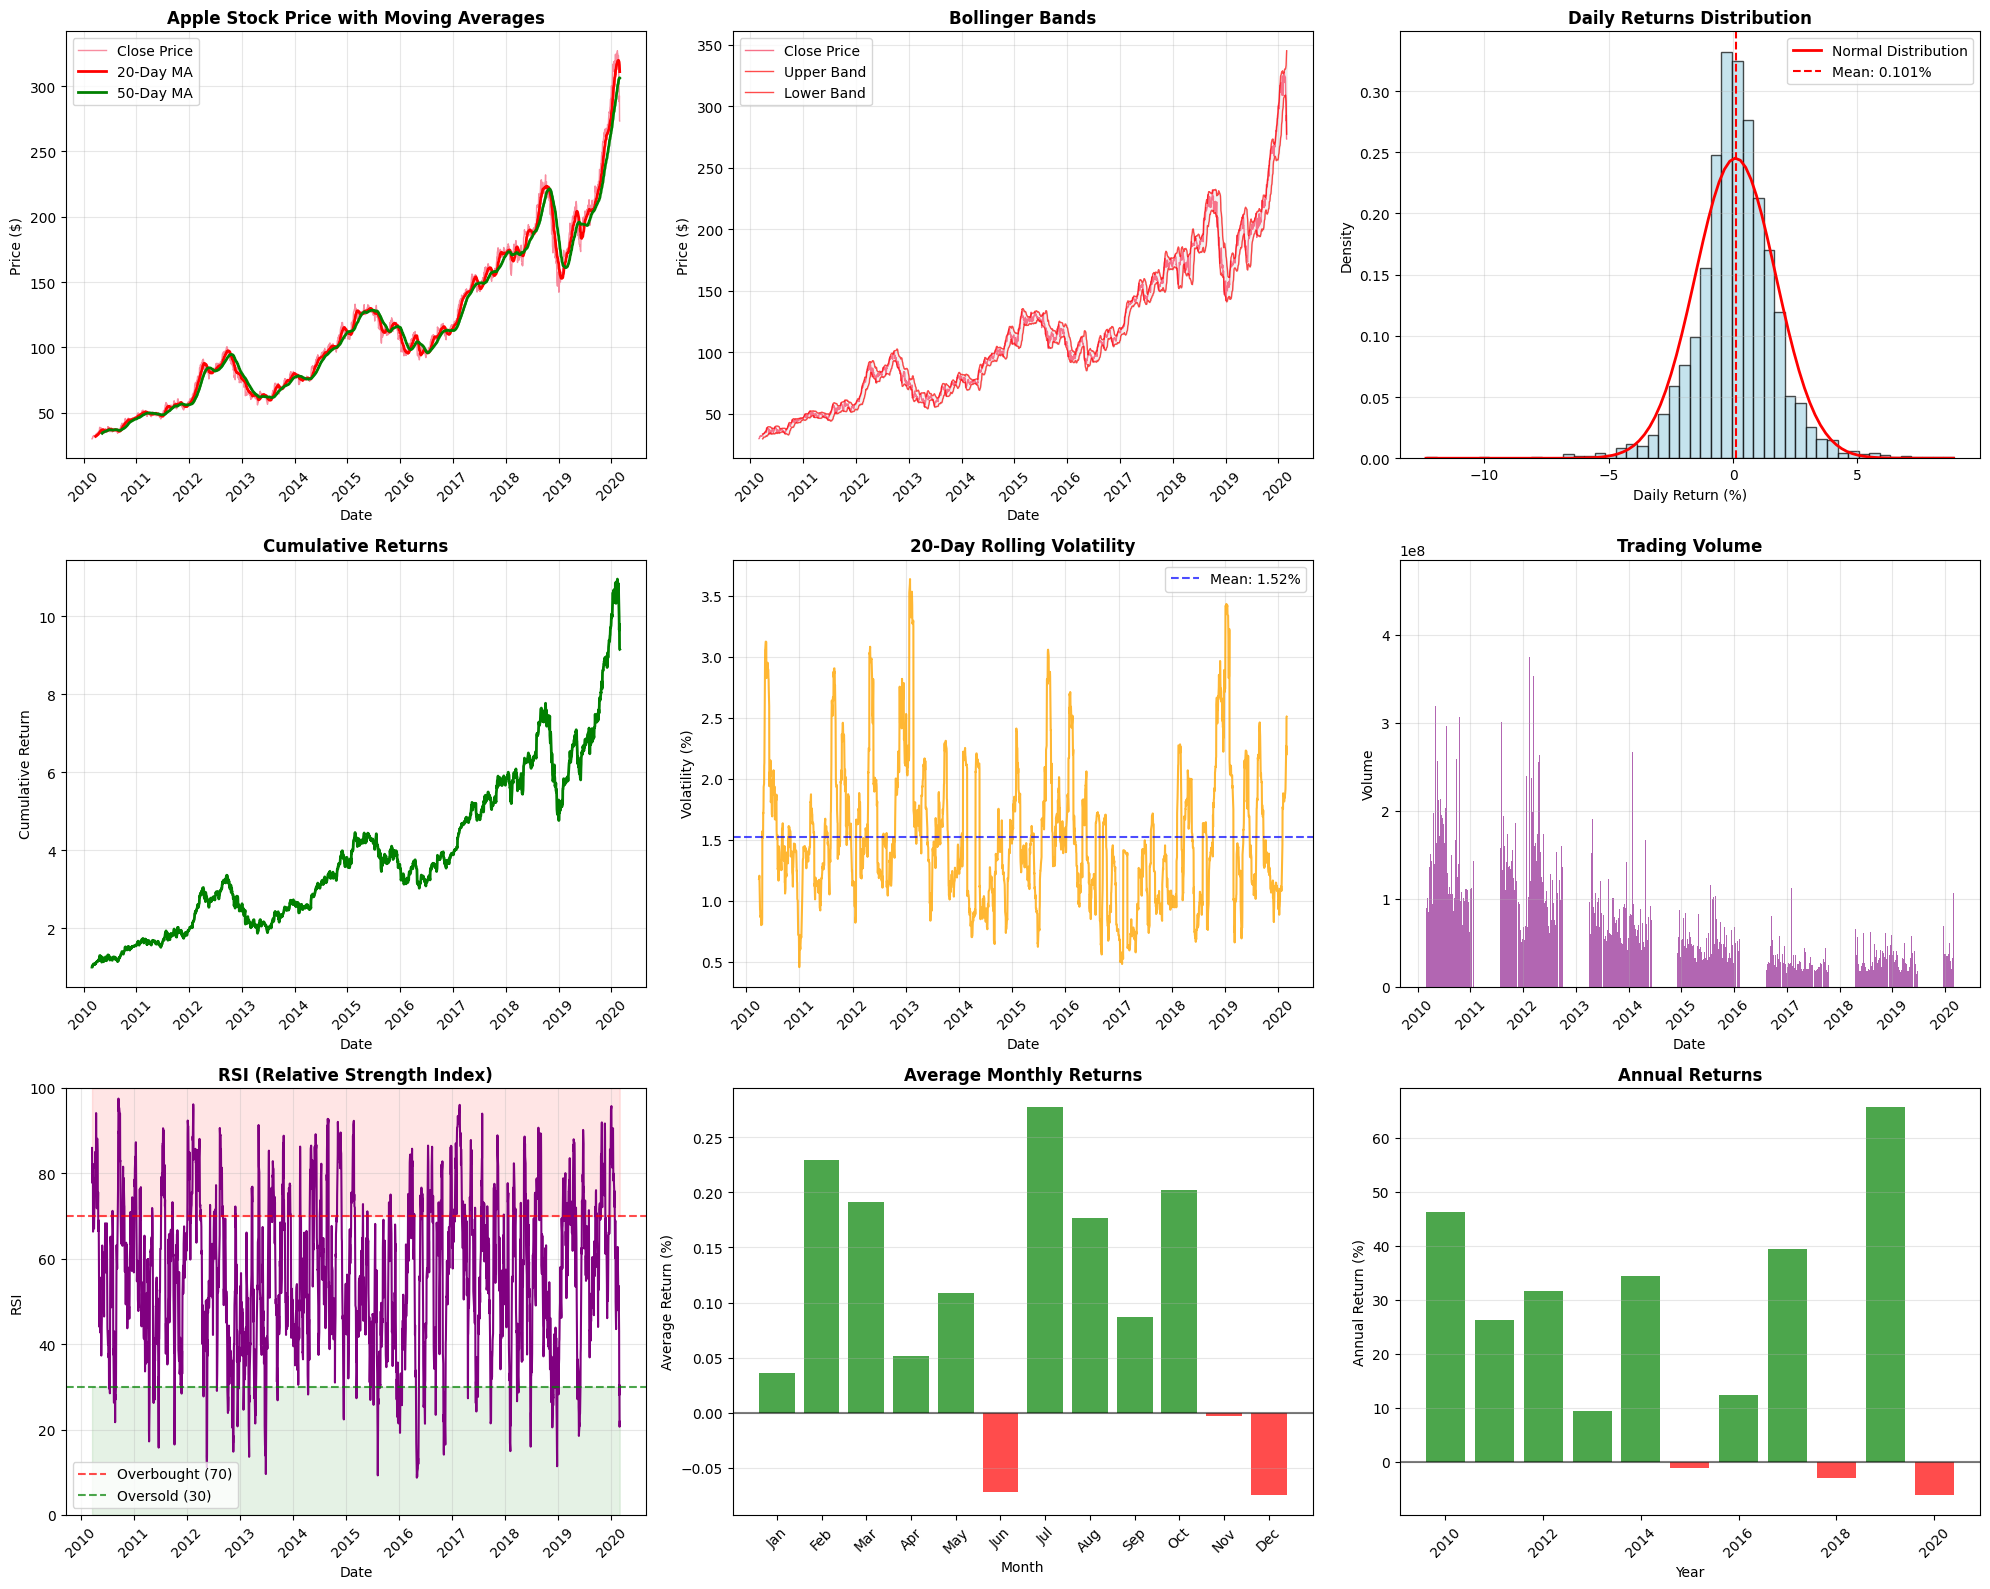

Visualization completed successfully.


In [8]:
# Task 5: Data Visualization

print("Creating comprehensive visualizations...")

# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 1. Stock Price with Moving Averages
ax1 = plt.subplot(3, 3, 1)
ax1.plot(df['Date'], df['Close'], linewidth=1, label='Close Price', alpha=0.8)
ax1.plot(df['Date'], df['MA_20'], linewidth=2, label='20-Day MA', color='red')
ax1.plot(df['Date'], df['MA_50'], linewidth=2, label='50-Day MA', color='green')
ax1.set_title('Apple Stock Price with Moving Averages', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Bollinger Bands
ax2 = plt.subplot(3, 3, 2)
ax2.plot(df['Date'], df['Close'], linewidth=1, label='Close Price')
ax2.plot(df['Date'], df['BB_Upper'], linewidth=1, label='Upper Band', color='red', alpha=0.7)
ax2.plot(df['Date'], df['BB_Lower'], linewidth=1, label='Lower Band', color='red', alpha=0.7)
ax2.fill_between(df['Date'], df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='gray')
ax2.set_title('Bollinger Bands', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Daily Returns Distribution
ax3 = plt.subplot(3, 3, 3)
returns_clean = df['Daily_Return'].dropna()
ax3.hist(returns_clean, bins=50, alpha=0.7, color='lightblue', edgecolor='black', density=True)
mu, sigma = returns_clean.mean(), returns_clean.std()
x = np.linspace(returns_clean.min(), returns_clean.max(), 100)
normal_curve = stats.norm.pdf(x, mu, sigma)
ax3.plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal Distribution')
ax3.axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.3f}%')
ax3.set_title('Daily Returns Distribution', fontweight='bold')
ax3.set_xlabel('Daily Return (%)')
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Cumulative Returns
ax4 = plt.subplot(3, 3, 4)
cumulative_returns = (1 + df['Daily_Return'].fillna(0) / 100).cumprod()
ax4.plot(df['Date'], cumulative_returns, linewidth=2, color='green')
ax4.set_title('Cumulative Returns', fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# 5. Volatility Over Time
ax5 = plt.subplot(3, 3, 5)
volatility_data = df[['Date', 'Volatility_20']].dropna()
ax5.plot(volatility_data['Date'], volatility_data['Volatility_20'], color='orange', alpha=0.8)
vol_mean = volatility_data['Volatility_20'].mean()
ax5.axhline(vol_mean, color='blue', linestyle='--', alpha=0.7, label=f'Mean: {vol_mean:.2f}%')
ax5.set_title('20-Day Rolling Volatility', fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('Volatility (%)')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.tick_params(axis='x', rotation=45)

# 6. Volume Analysis
ax6 = plt.subplot(3, 3, 6)
volume_data = df[['Date', 'Volume']].dropna()
ax6.bar(volume_data['Date'], volume_data['Volume'], alpha=0.6, color='purple', width=1)
ax6.set_title('Trading Volume', fontweight='bold')
ax6.set_xlabel('Date')
ax6.set_ylabel('Volume')
ax6.grid(True, alpha=0.3)
ax6.tick_params(axis='x', rotation=45)

# 7. RSI Indicator
ax7 = plt.subplot(3, 3, 7)
rsi_data = df[['Date', 'RSI']].dropna()
ax7.plot(rsi_data['Date'], rsi_data['RSI'], color='purple')
ax7.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax7.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax7.fill_between(rsi_data['Date'], 70, 100, alpha=0.1, color='red')
ax7.fill_between(rsi_data['Date'], 0, 30, alpha=0.1, color='green')
ax7.set_title('RSI (Relative Strength Index)', fontweight='bold')
ax7.set_xlabel('Date')
ax7.set_ylabel('RSI')
ax7.set_ylim(0, 100)
ax7.legend()
ax7.grid(True, alpha=0.3)
ax7.tick_params(axis='x', rotation=45)

# 8. Monthly Returns
ax8 = plt.subplot(3, 3, 8)
monthly_returns = df.groupby('Month')['Daily_Return'].mean()
months = list(range(1, 13))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
returns_values = [monthly_returns.get(m, 0) for m in months]
colors = ['green' if r > 0 else 'red' for r in returns_values]
ax8.bar(months, returns_values, alpha=0.7, color=colors)
ax8.set_title('Average Monthly Returns', fontweight='bold')
ax8.set_xlabel('Month')
ax8.set_ylabel('Average Return (%)')
ax8.set_xticks(months)
ax8.set_xticklabels(month_names, rotation=45)
ax8.axhline(0, color='black', linestyle='-', alpha=0.5)
ax8.grid(True, alpha=0.3, axis='y')

# 9. Annual Returns
ax9 = plt.subplot(3, 3, 9)
yearly_returns = df.groupby('Year')['Daily_Return'].sum()
colors = ['green' if r > 0 else 'red' for r in yearly_returns.values]
ax9.bar(yearly_returns.index, yearly_returns.values, alpha=0.7, color=colors)
ax9.set_title('Annual Returns', fontweight='bold')
ax9.set_xlabel('Year')
ax9.set_ylabel('Annual Return (%)')
ax9.axhline(0, color='black', linestyle='-', alpha=0.5)
ax9.grid(True, alpha=0.3, axis='y')
ax9.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualization completed successfully.")

## Task 6: Investment Analysis and Conclusions

In [12]:

print("=" * 60)

# Calculate key investment metrics
returns_data = df['Daily_Return'].dropna()
close_data = df['Close'].dropna()

# Performance metrics
total_return = ((close_data.iloc[-1] / close_data.iloc[0]) - 1) * 100
annual_return = returns_data.mean() * 252
annual_volatility = returns_data.std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0

# Risk metrics
var_95 = np.percentile(returns_data, 5)
max_daily_loss = returns_data.min()
max_daily_gain = returns_data.max()

# Technical indicators (current values)
current_price = close_data.iloc[-1]
current_rsi = df['RSI'].iloc[-1] if 'RSI' in df.columns else None
current_ma_20 = df['MA_20'].iloc[-1] if 'MA_20' in df.columns else None

print(f"\nKEY PERFORMANCE METRICS")
print(f"-" * 30)
print(f"Total Return: {total_return:.2f}%")
print(f"Annualized Return: {annual_return:.2f}%")
print(f"Annualized Volatility: {annual_volatility:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Current Price: ${current_price:.2f}")

print(f"\nRISK ASSESSMENT")
print(f"-" * 20)
print(f"Value at Risk (95%): {var_95:.4f}%")
print(f"Maximum Daily Loss: {max_daily_loss:.4f}%")
print(f"Maximum Daily Gain: {max_daily_gain:.4f}%")
print(f"Risk Rating: {'High' if annual_volatility > 30 else 'Medium' if annual_volatility > 20 else 'Low'}")

print(f"\nTECHNICAL ANALYSIS")
print(f"-" * 20)
if current_rsi is not None:
    if current_rsi > 70:
        rsi_signal = "Overbought - Consider Selling"
    elif current_rsi < 30:
        rsi_signal = "Oversold - Consider Buying"
    else:
        rsi_signal = "Neutral"
    print(f"Current RSI: {current_rsi:.2f} - {rsi_signal}")

if current_ma_20 is not None:
    trend_signal = "Bullish" if current_price > current_ma_20 else "Bearish"
    print(f"Trend (vs 20-day MA): {trend_signal}")

# Investment recommendation
print(f"\nINVESTMENT RECOMMENDATION")
print(f"-" * 30)

recommendation_score = 0
factors = []

# Performance factor
if annual_return > 15:
    recommendation_score += 2
    factors.append("Strong historical returns")
elif annual_return > 5:
    recommendation_score += 1
    factors.append("Positive historical returns")

# Risk factor
if annual_volatility < 20:
    recommendation_score += 1
    factors.append("Moderate volatility")
elif annual_volatility > 40:
    recommendation_score -= 1
    factors.append("High volatility")

# Sharpe ratio factor
if sharpe_ratio > 1:
    recommendation_score += 1
    factors.append("Good risk-adjusted returns")

# Technical factor
if current_rsi is not None:
    if 30 < current_rsi < 70:
        recommendation_score += 1
        factors.append("Balanced technical indicators")

print(f"Supporting Factors:")
for factor in factors:
    print(f"  - {factor}")

if recommendation_score >= 4:
    final_recommendation = "STRONG BUY"
elif recommendation_score >= 2:
    final_recommendation = "BUY"
elif recommendation_score >= 0:
    final_recommendation = "HOLD"
else:
    final_recommendation = "CAUTION"

print(f"\nFinal Recommendation: {final_recommendation}")
print(f"Recommendation Score: {recommendation_score}/5")

print(f"\nPORTFOLIO ALLOCATION SUGGESTIONS")
print(f"-" * 35)
if annual_volatility < 20:
    allocation = "5-15% of portfolio"
elif annual_volatility < 30:
    allocation = "3-10% of portfolio"
else:
    allocation = "1-5% of portfolio"

print(f"Suggested allocation: {allocation}")
print(f"Investment horizon: Long-term (>3 years) recommended")

print(f"\nKEY INSIGHTS")
print(f"-" * 15)
print(f"1. Apple stock shows {'strong' if total_return > 100 else 'moderate' if total_return > 50 else 'weak'} long-term performance")
print(f"2. Volatility is {'high' if annual_volatility > 30 else 'moderate' if annual_volatility > 20 else 'low'}, requiring careful position sizing")
print(f"3. Risk-adjusted returns (Sharpe ratio) are {'excellent' if sharpe_ratio > 1.5 else 'good' if sharpe_ratio > 1 else 'moderate'}")
print(f"4. Current technical indicators suggest {'bullish' if recommendation_score > 2 else 'neutral' if recommendation_score > 0 else 'bearish'} sentiment")

print(f"\nRISK MANAGEMENT RECOMMENDATIONS")
print(f"-" * 35)
print(f"- Use stop-loss orders at {var_95*2:.1f}% below entry price")
print(f"- Consider dollar-cost averaging for large positions")
print(f"- Monitor RSI for overbought/oversold conditions")
print(f"- Rebalance portfolio quarterly")

print(f"\nANALYSIS COMPLETED")
print(f"Data period: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total trading days analyzed: {len(df)}")
print(f"Statistical methods applied: SciPy hypothesis testing, normality tests, correlation analysis")
print(f"Visualization techniques: Matplotlib comprehensive charting")
print(f"Financial metrics: Performance, risk, and technical analysis")


KEY PERFORMANCE METRICS
------------------------------
Total Return: 815.60%
Annualized Return: 25.52%
Annualized Volatility: 25.83%
Sharpe Ratio: 0.9881
Current Price: $273.36

RISK ASSESSMENT
--------------------
Value at Risk (95%): -2.5044%
Maximum Daily Loss: -12.3550%
Maximum Daily Gain: 8.8741%
Risk Rating: Medium

TECHNICAL ANALYSIS
--------------------
Current RSI: 21.82 - Oversold - Consider Buying
Trend (vs 20-day MA): Bearish

INVESTMENT RECOMMENDATION
------------------------------
Supporting Factors:
  - Strong historical returns

Final Recommendation: BUY
Recommendation Score: 2/5

PORTFOLIO ALLOCATION SUGGESTIONS
-----------------------------------
Suggested allocation: 3-10% of portfolio
Investment horizon: Long-term (>3 years) recommended

KEY INSIGHTS
---------------
1. Apple stock shows strong long-term performance
2. Volatility is moderate, requiring careful position sizing
3. Risk-adjusted returns (Sharpe ratio) are moderate
4. Current technical indicators sugges